# Inspect the generated candidates.

## Prepare the notebook.

### Import the libraries.

In [1]:
import os
import sys
import yaml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

### Define constants.

In [2]:
RESULTS_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/results"
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/config/annotation/default.yaml"


### Read annotation configuration.

In [3]:
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
print(protocol_cols)

['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture']


## Load results data.

### Create joint data frame.

In [4]:
target_ct_list = os.listdir(RESULTS_DIR)
results_df = []
for ct in target_ct_list:
    ct_dir = os.path.join(RESULTS_DIR, ct)
    ct_runs = os.listdir(ct_dir)
    ct_runs = [os.path.join(ct_dir, run) for run in ct_runs]
    ct_runs = [run_dir for run_dir in ct_runs if os.path.isdir(run_dir)]
    print(f"{len(ct_runs)} runs found for {ct}")
    ct_df = []
    for run_dir in tqdm(ct_runs):
        run_df = pd.read_csv(
            os.path.join(run_dir, "candidates.csv"),
            index_col="sample_id"
        )
        run_df.index = pd.MultiIndex.from_tuples(
            run_df.index.str.split(":").map(tuple),
            names=["target_ct", "run_id", "sample_id"],
        )
        ct_df.append(run_df)
    ct_df = pd.concat(ct_df, axis=0)
    results_df.append(ct_df)
results_df = pd.concat(results_df, axis=0)
print(f"{results_df.shape=}")
results_df.head()

57 runs found for MgkPro


100%|██████████| 57/57 [00:04<00:00, 13.51it/s]


57 runs found for HSCs


100%|██████████| 57/57 [00:02<00:00, 19.14it/s]


57 runs found for EryPro


100%|██████████| 57/57 [00:02<00:00, 19.11it/s]


results_df.shape=(21375, 88)


gm-csf_[ng_ml]  tpo_[ng_ml]  \
target_ct run_id                       sample_id                                
MgkPro    2026-02-04_18-18-08_c84f58e3 0               17.624770    10.210222   
                                       1                2.922574     3.177480   
                                       2                3.100074     1.017854   
                                       3                0.000000     1.308831   
                                       4                2.714988     0.993052   

                                                      sr1_[nm]    um171_[nm]  \
target_ct run_id                       sample_id                               
MgkPro    2026-02-04_18-18-08_c84f58e3 0            290.729220   2360.225000   
                                       1            176.087550  39406.477000   
                                       2          24874.988000     69.910790   
                                       3           1216.892800      2.307611   
                                       4             95.741035    384.957820   

                                                  um729_[µm]  scf_[ng_ml]  \
target_ct run_id                       sample_id                            
MgkPro    2026-02-04_18-18-08_c84f58e3 0            0.000000   189.065610   
                                       1            0.000000   181.450620   
                                       2            0.000000     1.872095   
                                       3           10.995326    12.783007   
                                       4            1.542536    22.036495   

                                                  butyzamide_[nm]  \
target_ct run_id                       sample_id                    
MgkPro    2026-02-04_18-18-08_c84f58e3 0                 0.000000   
                                       1                 1.783156   
                                       2                 0.000000   
                                       3                 2.825279   
                                       4                 2.556230   

                                                  retinoic_acid_[µm]  \
target_ct run_id                       sample_id                       
MgkPro    2026-02-04_18-18-08_c84f58e3 0                    0.000000   
                                       1                    0.330803   
                                       2                    0.000000   
                                       3                    0.000000   
                                       4                    0.000000   

                                                  ldl_[ng_ml]  il3_[ng_ml]  \
target_ct run_id                       sample_id                             
MgkPro    2026-02-04_18-18-08_c84f58e3 0             0.479737     0.000000   
                                       1            28.058352     0.000000   
                                       2             0.000000     1.557738   
                                       3             0.496010     0.000000   
                                       4             0.000000     0.000000   

                                                  ...  \
target_ct run_id                       sample_id  ...   
MgkPro    2026-02-04_18-18-08_c84f58e3 0          ...   
                                       1          ...   
                                       2          ...   
                                       3          ...   
                                       4          ...   

                                                                                  cfg:sampling:mask  \
target_ct run_id                       sample_id                                                      
MgkPro    2026-02-04_18-18-08_c84f58e3 0          [False, False, True, True, False, False, False...   
                                       1          [False, False, True, True, False, False, False...   
                                 

### Optionally dump the concatenated dataframe.

In [12]:
dump_concatenated_data = True
if dump_concatenated_data:
    results_df.to_csv(
        os.path.join(RESULTS_DIR, "concatenated_results.csv")
    )

## Inspect unfiltered results.

### Group by cell type and display the distribution.

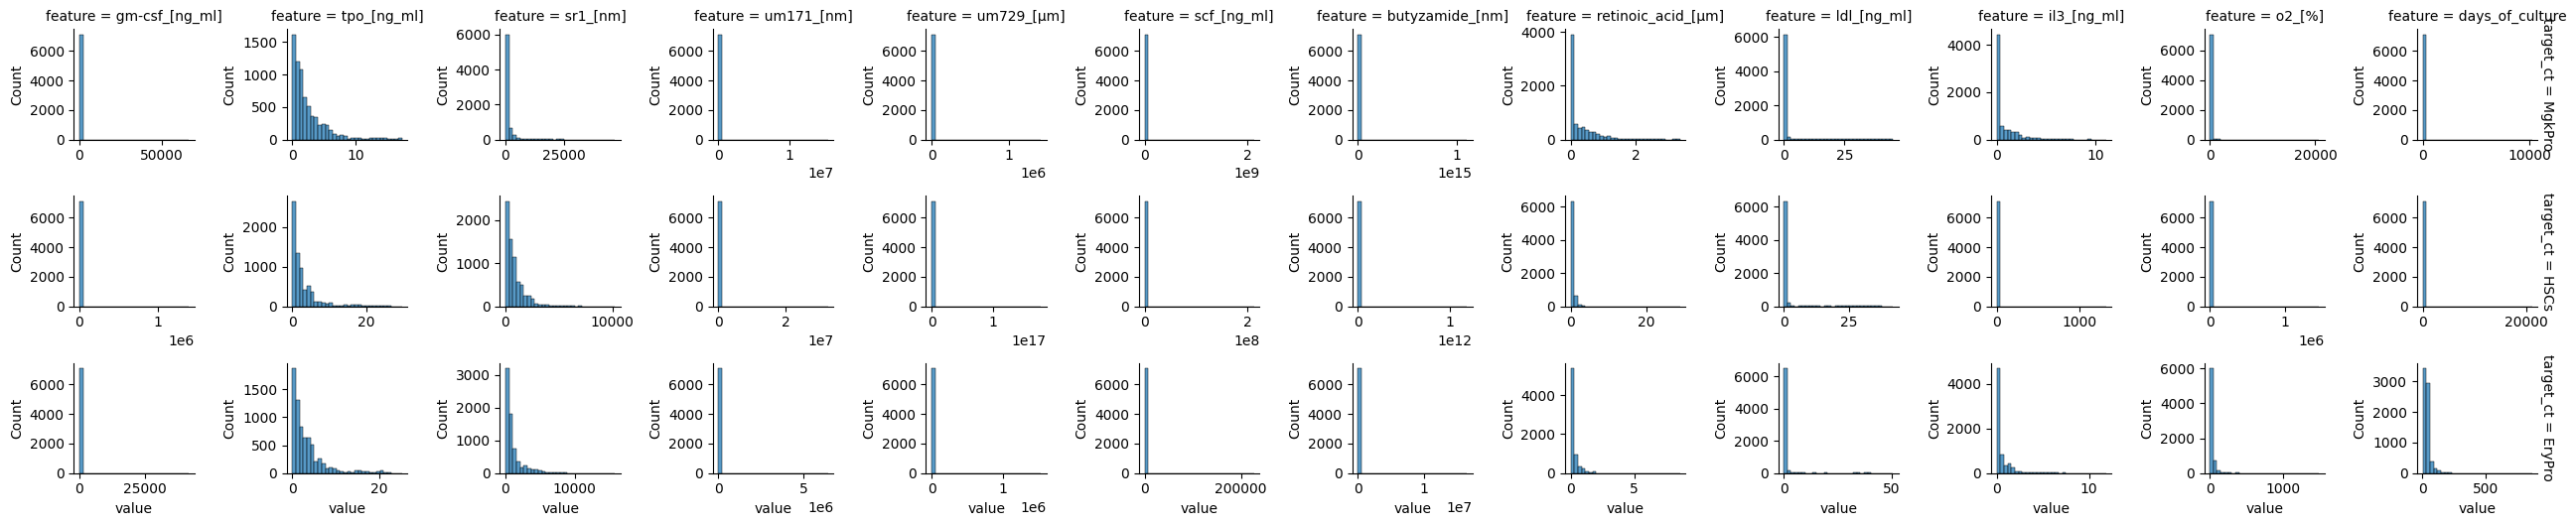

In [5]:
long_df = (
    results_df
    .reset_index(level="target_ct")
    .melt(
        id_vars="target_ct",
        value_vars=protocol_cols,
        var_name="feature",
        value_name="value",
    )
)
g = sns.FacetGrid(
    long_df,
    row="target_ct",
    col="feature",
    sharex=False,
    sharey=False,
    margin_titles=True,
    height=1.8,
    aspect=1.2,
)

g.map_dataframe(
    sns.histplot,
    x="value",
    bins=30,
)

plt.tight_layout()
plt.show()

### Plot target proportion.

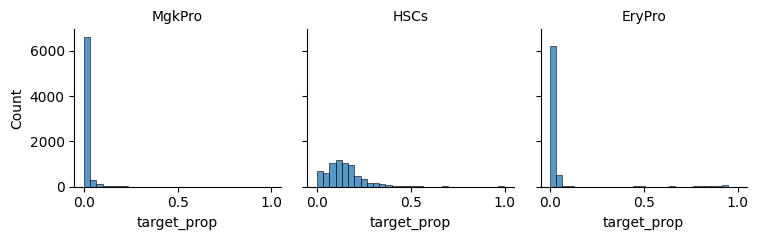

In [6]:
# Get target_ct as a column
df = results_df.reset_index(level="target_ct")

prop_cols = [col for col in results_df.columns if col.endswith("_prop")]

df = results_df.reset_index(level="target_ct")
col_idx = df.columns.get_indexer(df["target_ct"] + "_prop")
row_idx = np.arange(len(df))

df["target_prop"] = df.to_numpy()[row_idx, col_idx]

g = sns.FacetGrid(
    df,
    col="target_ct",
    col_wrap=4,
    sharex=True,
    sharey=True,
    height=2.5,
)

g.map_dataframe(
    sns.histplot,
    x="target_prop",
    bins=30,
)

g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### Scatter plot of target proportion against medium covariates.

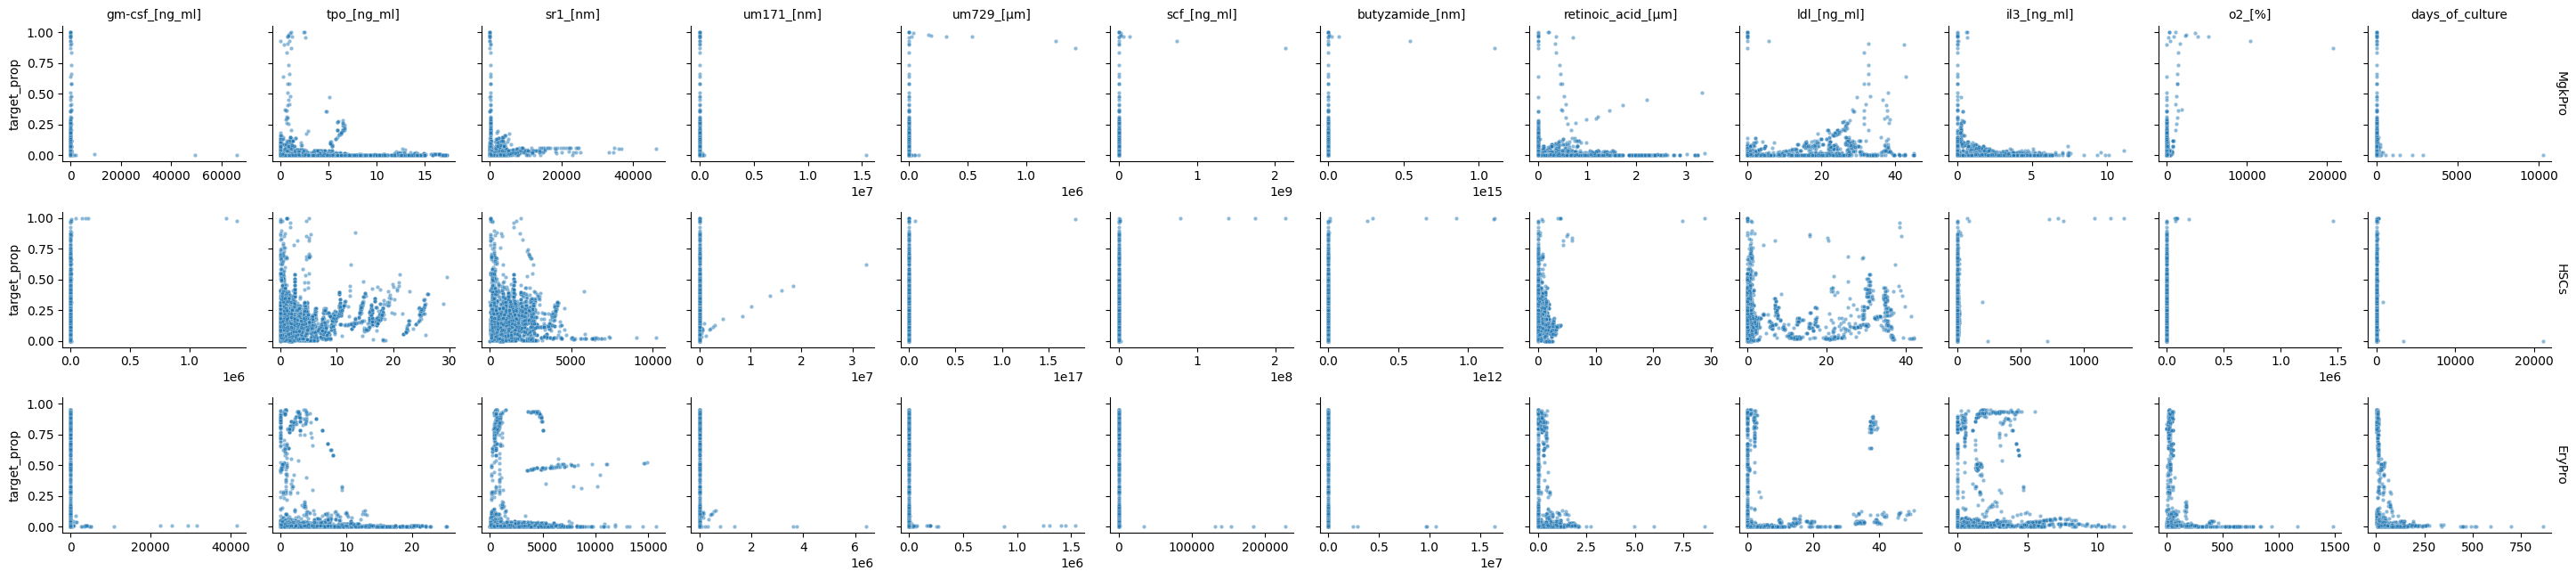

In [7]:
df = results_df.reset_index(level="target_ct")
col_idx = df.columns.get_indexer(df["target_ct"] + "_prop")
row_idx = np.arange(len(df))

df["target_prop"] = df.to_numpy()[row_idx, col_idx]

long_scatter = df.melt(
    id_vars=["target_ct", "target_prop"],
    value_vars=protocol_cols,
    var_name="protocol",
    value_name="protocol_value",
)

g = sns.FacetGrid(
    long_scatter,
    row="target_ct",
    col="protocol",
    sharex=False,
    sharey=True,
    height=2.2,
    aspect=1.1,
    margin_titles=True,
)

g.map_dataframe(
    sns.scatterplot,
    x="protocol_value",
    y="target_prop",
    s=10,
    alpha=0.5,
)

g.set_axis_labels("", "target_prop")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

plt.tight_layout()
plt.show()


### Plotting correlation between medium covariates for each target cell type

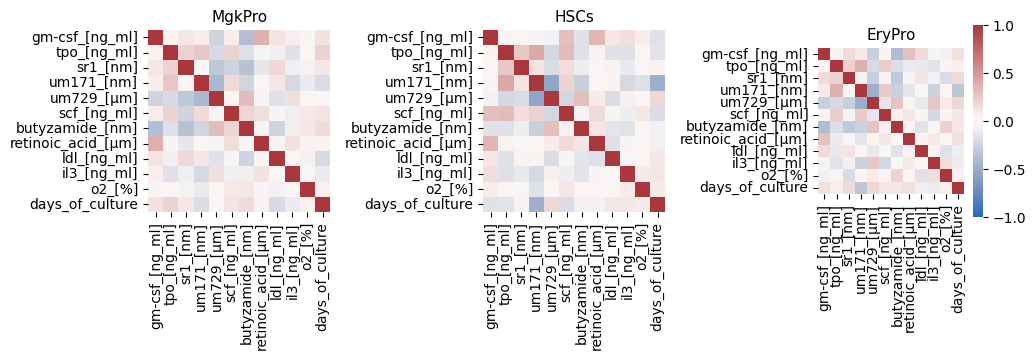

In [8]:
df = results_df.reset_index(level="target_ct")
cell_types = df["target_ct"].unique()
n_ct = len(cell_types)

fig, axes = plt.subplots(
    1, n_ct,
    figsize=(3.5 * n_ct, 3.5),
    squeeze=False,
)

for ax, ct in zip(axes[0], cell_types):
    sub = df[df["target_ct"] == ct][protocol_cols]

    # Correlation matrix
    corr = sub.corr(method="spearman")  # Spearman is usually better here

    sns.heatmap(
        corr,
        ax=ax,
        cmap="vlag",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        cbar=ax is axes[0, -1],  # only one colorbar
        xticklabels=True,
        yticklabels=True,
    )

    ax.set_title(ct, fontsize=11)
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


## Inspect filtered results.

### Filter results on oxygenation level and days of culture.

In [9]:
ox_lbound = 10.0
ox_ubound = 25.0

days_lbound = 13.0
days_ubound = 27.0

filtered_res_df = results_df.loc[
    (results_df["o2_[%]"] <= ox_ubound) &
    (results_df["o2_[%]"] >= ox_lbound) &
    (results_df["days_of_culture"] <= days_ubound) &
    (results_df["days_of_culture"] >= days_lbound)
]
print(f"{filtered_res_df.shape}")

(2463, 88)


### Scatter plot of protocol values.

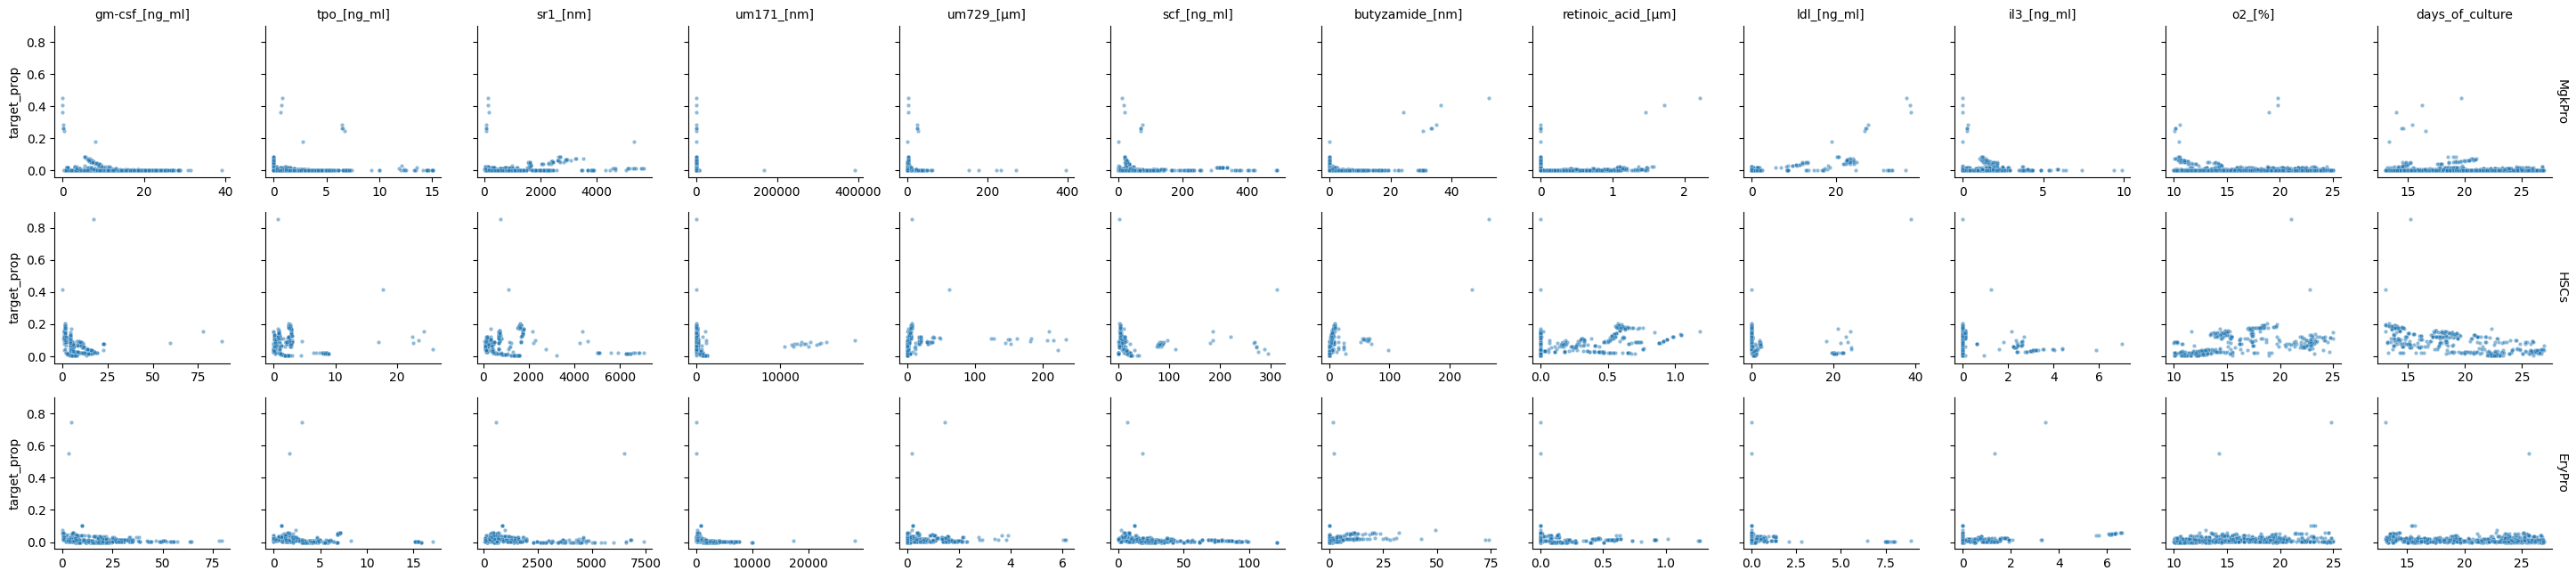

In [10]:
df = filtered_res_df.reset_index(level="target_ct")
col_idx = df.columns.get_indexer(df["target_ct"] + "_prop")
row_idx = np.arange(len(df))

df["target_prop"] = df.to_numpy()[row_idx, col_idx]

long_scatter = df.melt(
    id_vars=["target_ct", "target_prop"],
    value_vars=protocol_cols,
    var_name="protocol",
    value_name="protocol_value",
)

g = sns.FacetGrid(
    long_scatter,
    row="target_ct",
    col="protocol",
    sharex=False,
    sharey=True,
    height=2.2,
    aspect=1.1,
    margin_titles=True,
)

g.map_dataframe(
    sns.scatterplot,
    x="protocol_value",
    y="target_prop",
    s=10,
    alpha=0.5,
)

g.set_axis_labels("", "target_prop")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

plt.tight_layout()
plt.show()
